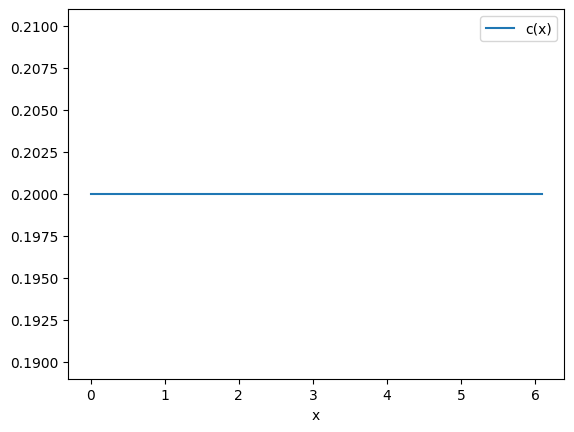

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import DiagonalGate, QFTGate, StatePreparation, UnitaryGate
from qiskit.quantum_info import Statevector
from scipy.linalg import expm

n_qubits = 5
N = 2**n_qubits
L = 2 * np.pi               
t = 10     
x = np.linspace(0, L, N, endpoint=False)
dx = L / N

# Parameters
c_val = 0.2
c = c_val * np.ones_like(x) 


plt.plot(x, c, label='c(x)')
plt.xlabel('x')
plt.legend()

In [11]:
# subroutine for QFT matrix (and its inverse) on n qubits
def get_qft_mat(n):
    num_states = 1<<n # this is 2**n
    omega = np.exp(-2j*np.pi/num_states)

    qft = np.zeros((num_states,num_states),dtype=complex)

    for i in range(num_states):
        for j in range(num_states):
            qft[i][j] = omega**(i*j)/np.sqrt(num_states)

    qft_inv = qft.transpose().conjugate()

    return qft, qft_inv

Success Probability: 1.0000e+00


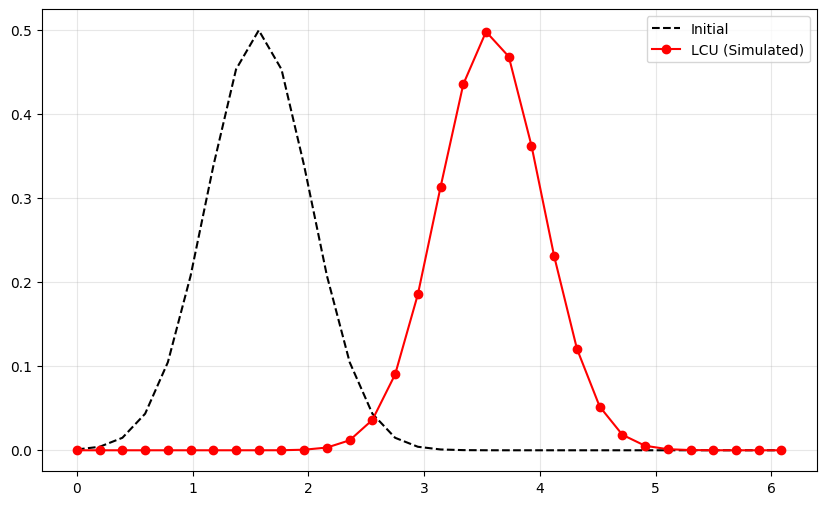

In [ ]:
from qiskit.quantum_info import SparsePauliOp, Operator   
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.synthesis import SuzukiTrotter
final_time = t


j_indices = np.arange(N)
k_indices = np.where(j_indices <= N/2, j_indices, j_indices - N)
P_1 = 1j * (2 * np.pi / L) * (k_indices)
qft, qft_inv = get_qft_mat(n_qubits)
Delta = qft_inv @ np.diag(P_1) @ qft 

H_a =  Delta @ np.diag(c)
H_b = np.diag(c) @ Delta

H_total = -0.5 * (H_a + H_b)
reg_s = QuantumRegister(n_qubits, 'system')
circuit = QuantumCircuit(reg_s)

sigma = L/20
state = np.exp(-0.25*((x-dx*N/4)/sigma)**2)
state = state / np.linalg.norm(state)
stateprep = StatePreparation(state)
circuit.append(stateprep,reg_s)

H_total = -0.5 * (H_a + H_b)
H_mat = 1j * H_total; 
H_herm = 0.5 * (H_mat + H_mat.conj().T)
H = SparsePauliOp.from_operator(Operator(H_herm))

# 2. Define the synthesis method (2nd order Trotter)
# This automatically handles the symmetric splitting: e^(B/2) e^A e^(B/2)
trotter_factory = SuzukiTrotter(order=2, reps=1)

# 3. Create the Gate
# time = 1.0 represents the simulation duration 't'
evolution_gate = PauliEvolutionGate(H, time=t, synthesis=trotter_factory)

circuit.append(evolution_gate, reg_s)


final_state = Statevector(circuit)
full_data = np.array(final_state)

system_state = full_data

success_prob = np.linalg.norm(system_state)**2
final = system_state / np.linalg.norm(system_state)

print(f"Success Probability: {success_prob:.4e}")

plt.figure(figsize=(10, 6))
plt.plot(x, state, 'k--', label='Initial')
plt.plot(x, np.real(final), 'ro-', label=f'LCU (Simulated)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

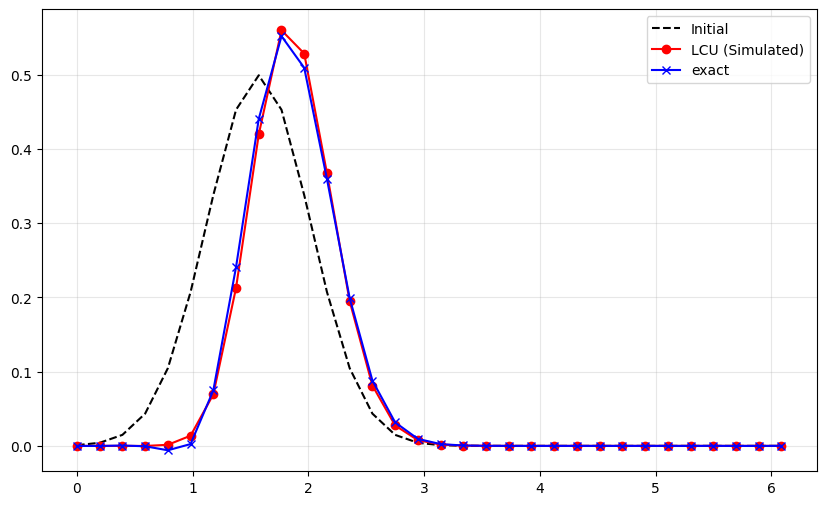

In [72]:

gamma_s = 1.0 / (2 * dx)


c_left = np.roll(c, 1)    # index i contains c_{i-1}
c_right = np.roll(c, -1)  # index i contains c_{i+1}

val_lower = gamma_s * c_left
val_upper = -gamma_s * c_right


M = np.diag(val_lower[1:], k=-1) + np.diag(val_upper[:-1], k=1)
M[0, N-1] = val_lower[0]
M[N-1, 0] = val_upper[N-1]
u_final = expm(M * t) @ state




plt.figure(figsize=(10, 6))
plt.plot(x, state, 'k--', label='Initial')
plt.plot(x, np.real(final), 'ro-', label=f'LCU (Simulated)')
plt.plot(x, u_final/np.linalg.norm(u_final), 'bx-', label=f'exact')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()